# Computer Modeling - Hands-On assignment week 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Part 1 - A simple Interaction model

In [3]:
## Lenard-Jones potential equation
def lj_energy(r,e = 1,s = 1):
    U = 4 * e * ((s/r)**12 - (s/r)**6)
    return U

r = np.linspace(0.95,3.0,1000)
# evaluate U(r)
U  = lj_energy(r,s = 1)
print(U)


[ 1.96097466  1.84175829  1.72672193  1.61572824  1.50864447  1.40534227
  1.30569759  1.2095905   1.11690504  1.02752911  0.9413543   0.85827582
  0.77819231  0.70100577  0.62662142  0.5549476   0.48589568  0.41937991
  0.35531737  0.29362785  0.23423377  0.17706007  0.12203416  0.0690858
  0.01814705 -0.03084784 -0.07796246 -0.12325836 -0.16679506 -0.20863019
 -0.24881949 -0.28741692 -0.32447466 -0.36004325 -0.39417156 -0.42690693
 -0.45829513 -0.4883805  -0.51720592 -0.54481292 -0.57124168 -0.59653111
 -0.62071886 -0.64384138 -0.66593395 -0.68703072 -0.70716477 -0.72636811
 -0.74467171 -0.76210559 -0.77869879 -0.79447943 -0.80947473 -0.82371106
 -0.83721394 -0.85000808 -0.86211741 -0.87356509 -0.88437355 -0.89456452
 -0.90415902 -0.91317743 -0.92163945 -0.92956419 -0.93697013 -0.94387517
 -0.95029666 -0.95625138 -0.96175559 -0.96682503 -0.97147494 -0.97572008
 -0.97957475 -0.98305279 -0.9861676  -0.98893215 -0.99135903 -0.99346039
 -0.99524802 -0.99673333 -0.99792737 -0.99884084 -0.

In [4]:
## Locate the minimum
min_idx = np.argmin(U)
print(f"Min index: {min_idx}" )
U_min = U[min_idx]
r_0 = r[min_idx]
print(f"R0: {r_0}")
print(f"Min Energy: {lj_energy(r_0)}")

Min index: 84
R0: 1.1223723723723724
Min Energy: -0.9999997700920915


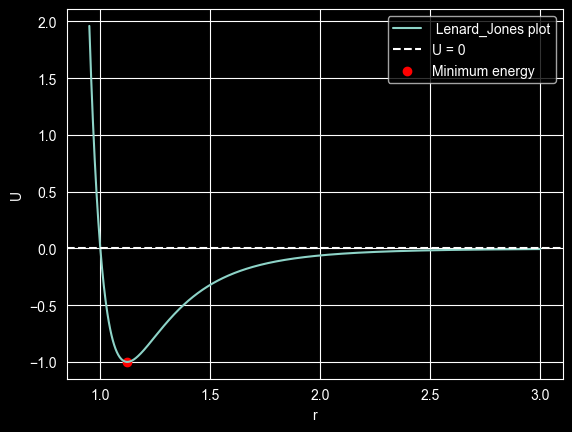

In [5]:
## plot
plt.plot(r,U,label = " Lenard_Jones plot")
plt.xlabel("r")
plt.ylabel("U")
plt.axhline(0, linestyle = "--", label = "U = 0")
plt.scatter(r_0,U_min,color = "red",label = "Minimum energy")
plt.legend()
plt.legend()
plt.show()

In [6]:
r0_numerical = r_0
r0_theorical = 2 **(1/6)

print(f"Numerical equilibrium separation r0 :",r0_numerical)
print(f"theorical equilibrium separation: ",r0_theorical)

print(f"Different between two r0: {r0_theorical - r0_numerical : .4f}")

Numerical equilibrium separation r0 : 1.1223723723723724
theorical equilibrium separation:  1.122462048309373
Different between two r0:  0.0001


## Part 2 - From Energy to Force

In [7]:
## Lenard_Jones Force
def lj_force (r,e = 1,s = 1):
    F = (24 ** e/r) * (2 * (s/r)**12 - (s/r)**6)
    return F

r = np.linspace(.95,3.0,1000)

# evaluate F
F = lj_force(r,e = 1,s = 1)
print(F)

[ 5.91375529e+01  5.70663315e+01  5.50631838e+01  5.31258355e+01
  5.12520914e+01  4.94398324e+01  4.76870127e+01  4.59916576e+01
  4.43518602e+01  4.27657795e+01  4.12316378e+01  3.97477184e+01
  3.83123636e+01  3.69239724e+01  3.55809984e+01  3.42819481e+01
  3.30253788e+01  3.18098969e+01  3.06341561e+01  2.94968558e+01
  2.83967393e+01  2.73325924e+01  2.63032420e+01  2.53075544e+01
  2.43444339e+01  2.34128219e+01  2.25116951e+01  2.16400644e+01
  2.07969739e+01  1.99814997e+01  1.91927483e+01  1.84298564e+01
  1.76919891e+01  1.69783393e+01  1.62881265e+01  1.56205963e+01
  1.49750190e+01  1.43506890e+01  1.37469240e+01  1.31630642e+01
  1.25984713e+01  1.20525281e+01  1.15246376e+01  1.10142222e+01
  1.05207233e+01  1.00436006e+01  9.58233117e+00  9.13640930e+00
  8.70534564e+00  8.28866673e+00  7.88591445e+00  7.49664555e+00
  7.12043108e+00  6.75685594e+00  6.40551845e+00  6.06602985e+00
  5.73801389e+00  5.42110643e+00  5.11495500e+00  4.81921844e+00
  4.53356652e+00  4.25767

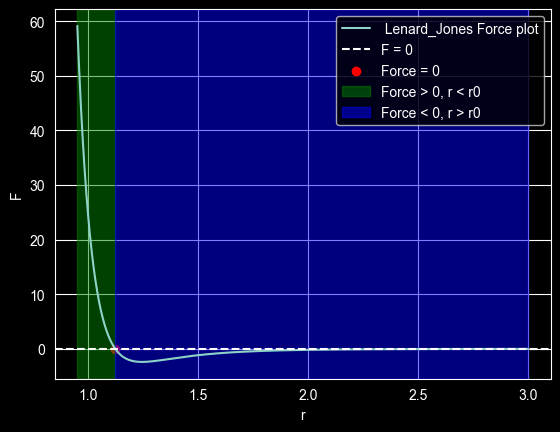

0.005128961298436561


In [8]:
## plot
plt.plot(r,F,label = " Lenard_Jones Force plot")
plt.axhline(0, linestyle = "--", label = "F = 0")
plt.scatter(r_0,F[min_idx],color = "red",label = "Force = 0")
plt.axvspan(.95,r_0,color = "green",label = "Force > 0, r < r0",alpha = 0.5)
plt.axvspan(r_0,3,color = "blue",label = "Force < 0, r > r0",alpha = 0.5)
plt.legend()
plt.legend()
plt.legend()
plt.xlabel("r")
plt.ylabel("F")
plt.legend()
plt.show()
print(F[min_idx])

In [9]:
# 2.2 — Check the energy–force relationship numerically
F_numeric = -np.gradient(U,r)
F_numeric

array([ 5.80961725e+01,  5.70776767e+01,  5.50741500e+01,  5.31364358e+01,
        5.12623385e+01,  4.94497385e+01,  4.76965898e+01,  4.60009168e+01,
        4.43608126e+01,  4.27744356e+01,  4.12400078e+01,  3.97558122e+01,
        3.83201906e+01,  3.69315416e+01,  3.55883187e+01,  3.42890280e+01,
        3.30322265e+01,  3.18165202e+01,  3.06405626e+01,  2.95030529e+01,
        2.84027340e+01,  2.73383916e+01,  2.63088523e+01,  2.53129820e+01,
        2.43496851e+01,  2.34179026e+01,  2.25166109e+01,  2.16448209e+01,
        2.08015765e+01,  1.99859533e+01,  1.91970581e+01,  1.84340271e+01,
        1.76960252e+01,  1.69822453e+01,  1.62919068e+01,  1.56242550e+01,
        1.49785601e+01,  1.43541164e+01,  1.37502414e+01,  1.31662752e+01,
        1.26015795e+01,  1.20555368e+01,  1.15275500e+01,  1.10170415e+01,
        1.05234526e+01,  1.00462427e+01,  9.58488900e+00,  9.13888558e+00,
        8.70774301e+00,  8.29098775e+00,  7.88816160e+00,  7.49882121e+00,
        7.12253756e+00,  

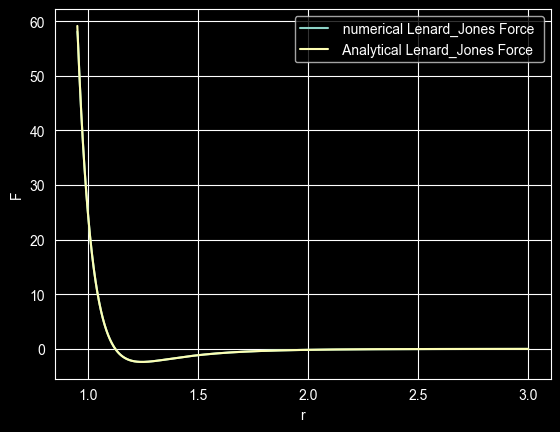

In [10]:
# Compare Analytical F and Numerical F
plt.plot(r,F_numeric,label = " numerical Lenard_Jones Force ")
plt.plot(r,F,label = " Analytical Lenard_Jones Force ")
plt.xlabel("r")
plt.ylabel("F")
plt.legend()
plt.show()

## Part 3 - Estimate the curvature numerically - Microscopic stiffness

In [42]:
## k_pair calculation
r_0 = 2 **(1/6)
r_0
h = 1e-4
U_0 = lj_energy(r_0,e=1,s = 1)
U_plus = lj_energy(r_0+h ,e=1,s = 1)
U_minus =  lj_energy(r_0-h ,e=1,s = 1)

k_pair = (U_plus - 2 * U_0 + U_minus) / h ** 2
print(f"K_pair (Curvature, Stiffness): {k_pair}")

K_pair (Curvature, Stiffness): 57.1464519039111


In [43]:
## K_par while sigma is fixed and epsilon increases
e = [0.5,1.0, 2.0]
k_pair = []
for i in e:
    U_0 = lj_energy(r_0,e=i,s = 1)
    U_plus = lj_energy(r_0+h ,e=i,s = 1)
    U_minus =  lj_energy(r_0-h ,e=i,s = 1)

    k_p = (U_plus - 2 * U_0 + U_minus) / h ** 2
    k_pair.append(k_p)


print(k_pair)

[28.57322595195555, 57.1464519039111, 114.2929038078222]


## part 4 - Form a pair interaction to a simple material

In [44]:
## 4-1 : Stretch the chain computationally
N = 20
r0 = 2 **(1/6)
L0 = (N-1) * r0

strain = np.linspace(-0.03,.03,301)


In [45]:
## calculate L
# strai = L - L0 / L0
L = L0 * ( 1 +strain )
print(len(L))
print("Nes L for each strain: ")
print(L)

301
Nes L for each strain: 
[20.68697555 20.69124091 20.69550626 20.69977162 20.70403697 20.70830233
 20.71256769 20.71683304 20.7210984  20.72536375 20.72962911 20.73389446
 20.73815982 20.74242518 20.74669053 20.75095589 20.75522124 20.7594866
 20.76375195 20.76801731 20.77228267 20.77654802 20.78081338 20.78507873
 20.78934409 20.79360944 20.7978748  20.80214016 20.80640551 20.81067087
 20.81493622 20.81920158 20.82346694 20.82773229 20.83199765 20.836263
 20.84052836 20.84479371 20.84905907 20.85332443 20.85758978 20.86185514
 20.86612049 20.87038585 20.8746512  20.87891656 20.88318192 20.88744727
 20.89171263 20.89597798 20.90024334 20.9045087  20.90877405 20.91303941
 20.91730476 20.92157012 20.92583547 20.93010083 20.93436619 20.93863154
 20.9428969  20.94716225 20.95142761 20.95569296 20.95995832 20.96422368
 20.96848903 20.97275439 20.97701974 20.9812851  20.98555046 20.98981581
 20.99408117 20.99834652 21.00261188 21.00687723 21.01114259 21.01540795
 21.0196733  21.02393866 2

In [46]:
## Calculate the new nearest-neighbor separation r:
r_nn = L / (N-1)
print(len(r_nn))
print("r_nn for each strain: ")

r_nn

301
r_nn for each strain: 


array([1.08878819, 1.08901268, 1.08923717, 1.08946166, 1.08968616,
       1.08991065, 1.09013514, 1.09035963, 1.09058413, 1.09080862,
       1.09103311, 1.0912576 , 1.0914821 , 1.09170659, 1.09193108,
       1.09215557, 1.09238007, 1.09260456, 1.09282905, 1.09305354,
       1.09327804, 1.09350253, 1.09372702, 1.09395151, 1.094176  ,
       1.0944005 , 1.09462499, 1.09484948, 1.09507397, 1.09529847,
       1.09552296, 1.09574745, 1.09597194, 1.09619644, 1.09642093,
       1.09664542, 1.09686991, 1.09709441, 1.0973189 , 1.09754339,
       1.09776788, 1.09799238, 1.09821687, 1.09844136, 1.09866585,
       1.09889035, 1.09911484, 1.09933933, 1.09956382, 1.09978831,
       1.10001281, 1.1002373 , 1.10046179, 1.10068628, 1.10091078,
       1.10113527, 1.10135976, 1.10158425, 1.10180875, 1.10203324,
       1.10225773, 1.10248222, 1.10270672, 1.10293121, 1.1031557 ,
       1.10338019, 1.10360469, 1.10382918, 1.10405367, 1.10427816,
       1.10450266, 1.10472715, 1.10495164, 1.10517613, 1.10540

In [47]:
def U(r, epsilon=1.0, sigma=1.0):
    return 4 * epsilon * ((sigma/r)**12 - (sigma/r)**6)

U_tot = (N-1) * U(r_nn)
print(len(U_tot))
print("Total Potential for each strain: ")
U_tot

301
Total Potential for each strain: 


array([-18.23603876, -18.24730549, -18.25847246, -18.26954006,
       -18.28050867, -18.29137867, -18.30215045, -18.3128244 ,
       -18.32340089, -18.3338803 , -18.34426301, -18.3545494 ,
       -18.36473985, -18.37483472, -18.3848344 , -18.39473925,
       -18.40454964, -18.41426595, -18.42388854, -18.43341777,
       -18.44285402, -18.45219764, -18.46144901, -18.47060847,
       -18.4796764 , -18.48865315, -18.49753907, -18.50633453,
       -18.51503988, -18.52365547, -18.53218166, -18.54061879,
       -18.54896723, -18.55722731, -18.56539938, -18.57348379,
       -18.58148089, -18.58939103, -18.59721453, -18.60495175,
       -18.61260302, -18.62016869, -18.62764909, -18.63504456,
       -18.64235544, -18.64958205, -18.65672474, -18.66378383,
       -18.67075966, -18.67765256, -18.68446285, -18.69119086,
       -18.69783693, -18.70440136, -18.71088449, -18.71728665,
       -18.72360815, -18.72984931, -18.73601045, -18.7420919 ,
       -18.74809396, -18.75401696, -18.75986121, -18.76

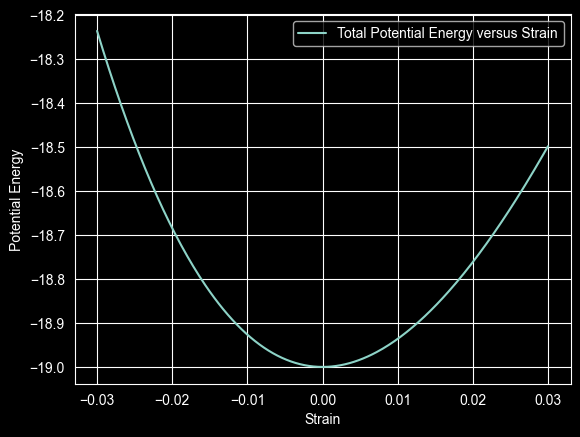

In [48]:
# Plot
plt.plot (strain,U_tot,label = "Total Potential Energy versus Strain")
plt.xlabel("Strain")
plt.ylabel("Potential Energy")
plt.legend()


In [49]:
# At approximately what strain is the minimum energy found?   Should this result have been expected?

# r_new = r0(1 + strain)

min_idx = np.argmin(U_tot)
strain_min = strain[min_idx]
U_tot_min = U_tot[min_idx]

print(f"strain_min: {strain_min}")
print(f"U_tot_min: {U_tot_min}")

strain_min: 0.0
U_tot_min: -19.0


In [50]:
## 4-2  Obtain the force–extension response
P = np.gradient(U_tot,L)
print(P)


[-2.64145250e+00 -2.62975790e+00 -2.60641416e+00 -2.58316119e+00
 -2.55999866e+00 -2.53692625e+00 -2.51394366e+00 -2.49105056e+00
 -2.46824664e+00 -2.44553159e+00 -2.42290509e+00 -2.40036683e+00
 -2.37791651e+00 -2.35555381e+00 -2.33327843e+00 -2.31109006e+00
 -2.28898839e+00 -2.26697312e+00 -2.24504395e+00 -2.22320057e+00
 -2.20144269e+00 -2.17976999e+00 -2.15818219e+00 -2.13667899e+00
 -2.11526008e+00 -2.09392517e+00 -2.07267397e+00 -2.05150618e+00
 -2.03042150e+00 -2.00941966e+00 -1.98850035e+00 -1.96766329e+00
 -1.94690818e+00 -1.92623475e+00 -1.90564269e+00 -1.88513174e+00
 -1.86470159e+00 -1.84435197e+00 -1.82408260e+00 -1.80389319e+00
 -1.78378346e+00 -1.76375313e+00 -1.74380193e+00 -1.72392957e+00
 -1.70413578e+00 -1.68442028e+00 -1.66478279e+00 -1.64522305e+00
 -1.62574078e+00 -1.60633571e+00 -1.58700756e+00 -1.56775606e+00
 -1.54858096e+00 -1.52948197e+00 -1.51045883e+00 -1.49151128e+00
 -1.47263904e+00 -1.45384186e+00 -1.43511947e+00 -1.41647160e+00
 -1.39789800e+00 -1.37939

In [51]:
delta_L = L - L0
delta_L

array([-0.63980337, -0.63553801, -0.63127266, -0.6270073 , -0.62274194,
       -0.61847659, -0.61421123, -0.60994588, -0.60568052, -0.60141517,
       -0.59714981, -0.59288445, -0.5886191 , -0.58435374, -0.58008839,
       -0.57582303, -0.57155767, -0.56729232, -0.56302696, -0.55876161,
       -0.55449625, -0.5502309 , -0.54596554, -0.54170018, -0.53743483,
       -0.53316947, -0.52890412, -0.52463876, -0.52037341, -0.51610805,
       -0.51184269, -0.50757734, -0.50331198, -0.49904663, -0.49478127,
       -0.49051592, -0.48625056, -0.4819852 , -0.47771985, -0.47345449,
       -0.46918914, -0.46492378, -0.46065842, -0.45639307, -0.45212771,
       -0.44786236, -0.443597  , -0.43933165, -0.43506629, -0.43080093,
       -0.42653558, -0.42227022, -0.41800487, -0.41373951, -0.40947416,
       -0.4052088 , -0.40094344, -0.39667809, -0.39241273, -0.38814738,
       -0.38388202, -0.37961666, -0.37535131, -0.37108595, -0.3668206 ,
       -0.36255524, -0.35828989, -0.35402453, -0.34975917, -0.34

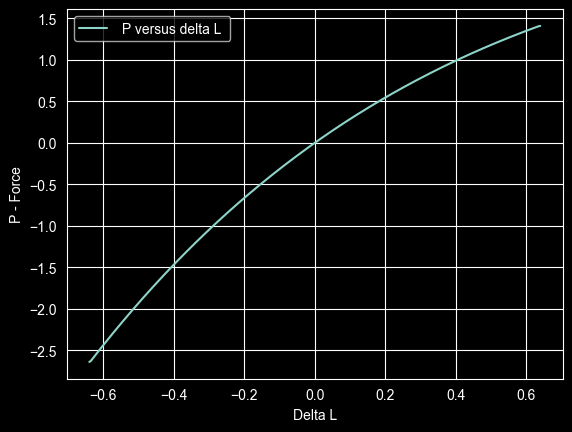

In [52]:
plt.plot(delta_L,P,label = " P versus delta L ")
plt.ylabel("P - Force")
plt.xlabel("Delta L")
plt.legend()

## Part 5 - Connecting microscopic and macroscopic stiffness

If every individual bond has the same stiffness, why does a chain with more bonds become easier to stretch?

In [53]:
# selecting small region of defirmation
mask = np.abs(strain) <= 0.01


In [54]:
# Fit a straight line: P = K_chain * delta_L + intercept
# the slope of this is fitted chain stiffness
coeff = np.polyfit(delta_L[mask],P[mask],1)
k_chain_fit = coeff[0]
print(coeff)
print(k_chain_fit)

[ 3.01255302 -0.02246923]
3.01255301819578


In [55]:
## k_pair calculation
r_0 = 2 **(1/6)
r_0
h = 1e-4
U_0 = lj_energy(r_0,e=1,s = 1)
U_plus = lj_energy(r_0+h ,e=1,s = 1)
U_minus =  lj_energy(r_0-h ,e=1,s = 1)

k_pair = (U_plus - 2 * U_0 + U_minus) / h ** 2
print(f"K_pair (Curvature, Stiffness): {k_pair}")

K_pair (Curvature, Stiffness): 57.1464519039111


In [56]:
k_chain_pred = k_pair / (N - 1)
k_chain_pred

3.0077079949426895

When identical bonds are connected in series, the same force acts on each bond, and the total extension is the sum of the extensions of the individual bonds. Therefore, adding more bonds increases the total extension under the same applied force, making the chain easier to stretch. The stiffness of each individual bond remains unchanged, while the overall chain stiffness decreases as the number of bonds increases.

More bonds in series → greater total extension → lower overall stiffness.

Fewer bonds in series → smaller total extension → higher overall stiffness.

## Part6 - What we did actually model ?


Our chain model is simplified and misses several important features of a real bulk solid :

- Dimenstionality: real solid and systems are three-dimentional
- Atomic Structure: Real atoms form complex crysatl or amporphos structure
- Interactions: Atoms interact with more than just their nearest neighbors.
- Temp: model ignores the thermal vibration and efffect


What has changed in the microscopic description used here?

- Instead of assuming the materials' stiffness, here we calculated the stiffness from the curvature of Potentila energy near the equilibrium separation (calculated form interaction between atoms)

Write 2–3 sentences explaining the connection between
interatomic potential → microscopic stiffness → macroscopic mechanical response:

First, we calculated the potential energy between two atoms (interatomic interaction). Then, we derived the microscopic stiffness from the curvature of the potential energy near the equilibrium distance. Finally, the stiffness of individual bonds determines the overall stiffness of the atomic chain, helping us understand the macroscopic mechanical response of a material.